In [1]:
# 6, 11, 18
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import time

In [2]:
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit

# Utility for fitting algorithm N complexity

def fit_to_models(title, x, y, models, model_labels, axis_labels=('x', 'y')):
    # Fit the data to both models
    params_x = []
    y_preds = []
    r_xs = []
    for i, model in enumerate(models):
        params_for_model_x, _ = curve_fit(model, x, y)
        params_x.append(params_for_model_x)
        y_pred = model(x, *params_for_model_x)
        y_preds.append(y_pred)
        r = r2_score(y, y_pred)
        r_xs.append(r)
        plt.plot(x, y_pred, label=f'Fit: y = {params_for_model_x[0]:.2e}{model_labels[i]} (R² = {r:.2f})')

    # Plotting the data and the fits
    plt.scatter(x, y, label='Data', color='black')
    plt.xlabel(axis_labels[0])
    plt.ylabel(axis_labels[1])
    plt.legend()
    plt.title(title)
    plt.show()

def model_x(x, a):
    return a * x

# define models
def model_x2(x, a):
    return a * x*x

def model_x3(x, a):
    return a * x*x*x

In [3]:
def I(n, shift=0):
  return np.eye(n, k=shift)

def magnitude(vector):
  if vector.shape[0] != 1:
    return math.sqrt(sum(c*c for c in vector))
  return math.sqrt(np.dot(vector, vector))

In [4]:
def tri_matrix(n, vals3):
  matrix = I(n) * vals3[1]
  matrix = matrix + I(n, 1) * vals3[0]
  matrix = matrix + I(n, -1) * vals3[2]
  return matrix

tri_matrix(4, (-1,2,-1))

array([[ 2., -1.,  0.,  0.],
       [-1.,  2., -1.,  0.],
       [ 0., -1.,  2., -1.],
       [ 0.,  0., -1.,  2.]])

In [7]:
# 6 Cholesky method
def cholesky_decompose(matrix):
  # L = np.linalg.cholesky(matrix)
  L = np.zeros_like(matrix)
  for i in range(matrix.shape[0]):
    for j in range(i + 1):
      sum_k = np.dot(L[i, :j], L[j, :j])
      if i == j:
        L[i, j] = np.sqrt(A[i, i] - sum_k)
      else:
        L[i, j] = (A[i, j] - sum_k) / L[j, j]
  return L

def solve_triangular(A, b, lower=True):
  x = np.zeros_like(b)
  if lower:
    iter_range = range(A.shape[0])
  else:
    iter_range = range(A.shape[0] - 1, -1, -1)
  for row in iter_range:
    x[row] = (b[row] - np.dot(A[row], x)) / A[row, row]
  return x

N = 20
A = tri_matrix(N, (-1,2,-1))
L = cholesky_decompose(A)
L_T = np.transpose(L)

print(f'A:\n{A}')
print(f'L:\n{L}')
print(f'L real:\n{np.linalg.cholesky(A)}')

def solve_system(L, L_T, b):
  y = solve_triangular(L, b, lower=True)
  x = solve_triangular(L_T, y, lower=False)
  return x

df = pd.DataFrame(columns=['iter.i', 'absolute error', 'max norm error', *(f'x_(i)_{k+1}' for k in range(N))])

def iter_solve(L, L_T, F, x, MAX_ITER_COUNT, MIN_CONVERGENCE_ERROR):
  for i in range(MAX_ITER_COUNT):
    x_prev = np.copy(x)
    b = F(x)
    x = solve_system(L, L_T, F(x))
    max_norm_error = np.max(np.abs(x - x_prev))
    # abs_error = magnitude(A @ x - b)
    abs_error = np.max(np.abs(A @ x - b))
    df.loc[len(df.index)] = [i+1, abs_error, max_norm_error, *(x_i[0] for x_i in x)]
    if max_norm_error < MIN_CONVERGENCE_ERROR:
      break

c = 1 / (1 + N) ** 2
F = lambda x: c * (np.multiply(x, x) + 1)
x = np.zeros((N, 1))
MIN_CONVERGENCE_ERROR = 1e-5
MAX_ITER_COUNT = 10
iter_solve(L, L_T, F, x, MAX_ITER_COUNT, MIN_CONVERGENCE_ERROR)
df

A:
[[ 2. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.]
 [-1.  2. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.]
 [ 0. -1.  2. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.]
 [ 0.  0. -1.  2. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.]
 [ 0.  0.  0. -1.  2. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.]
 [ 0.  0.  0.  0. -1.  2. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.]
 [ 0.  0.  0.  0.  0. -1.  2. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  2. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.  2. -1.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. -1.  2. -1.  0.  0.  0.  0.  0.  0.  0.
   0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. -1.  2. -1.  0.  0.  0.  0.  0.  0.
   0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.  2. -1.  0.  0. 

,iter.i,absolute error,max norm error,x_(i)_1,x_(i)_2,x_(i)_3,x_(i)_4,x_(i)_5,x_(i)_6,x_(i)_7,...,x_(i)_11,x_(i)_12,x_(i)_13,x_(i)_14,x_(i)_15,x_(i)_16,x_(i)_17,x_(i)_18,x_(i)_19,x_(i)_20
0,1.0,4.380177e-17,1.247166e-01,0.022676,0.043084,0.061224,0.077098,0.090703,0.102041,0.111111,...,0.124717,0.122449,0.117914,0.111111,0.102041,0.090703,0.077098,0.061224,0.043084,0.022676
1,2.0,4.770490e-17,1.430821e-03,0.022874,0.043480,0.061813,0.077871,0.091647,0.103138,0.112337,...,0.126147,0.123845,0.119240,0.112337,0.103138,0.091647,0.077871,0.061813,0.043480,0.022874
2,3.0,4.423545e-17,3.197535e-05,0.022879,0.043488,0.061826,0.077888,0.091668,0.103162,0.112364,...,0.126179,0.123876,0.119270,0.112364,0.103162,0.091668,0.077888,0.061826,0.043488,0.022879
3,4.0,3.989864e-17,7.162941e-07,0.022879,0.043488,0.061826,0.077888,0.091669,0.103162,0.112364,...,0.126180,0.123876,0.119270,0.112364,0.103162,0.091669,0.077888,0.061826,0.043488,0.022879


In [13]:
def iter_solve_cholesky(L, L_T, F, x, MAX_ITER_COUNT, MIN_CONVERGENCE_ERROR):
  for _ in range(MAX_ITER_COUNT):
    x_prev = np.copy(x)
    x = solve_system(L, L_T, F(x))
    max_norm_error = np.max(np.abs(x - x_prev))
    if max_norm_error < MIN_CONVERGENCE_ERROR:
      break

MIN_CONVERGENCE_ERROR = 1e-6
MAX_ITER_COUNT = 500
def F(c): 
  return lambda x: c * (np.multiply(x, x) + 1)

In [32]:
# Just solution time
Ns = range(100, 1500, 20)
times_for_solution_Ns = []
for N in Ns:
  A = tri_matrix(N, (-1,2,-1))
  L = cholesky_decompose(A)
  L_T = np.transpose(L)
  x = np.zeros((N, 1))
  c = 1 / (1 + N) ** 2
  start_time = time.time()
  iter_solve_cholesky(L, L_T, F(c), x, MAX_ITER_COUNT, MIN_CONVERGENCE_ERROR)
  times_for_solution_Ns.append(time.time() - start_time)

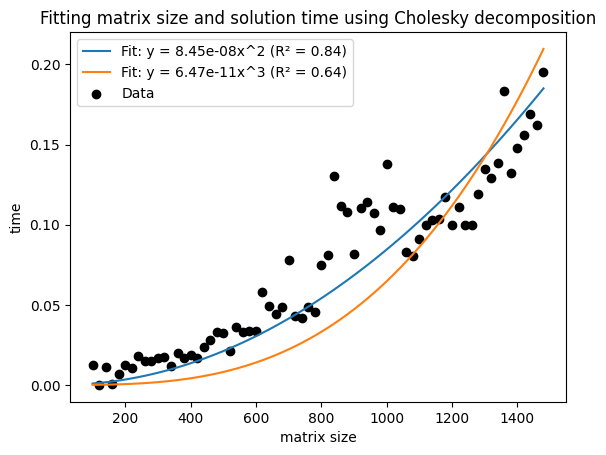

In [33]:
fit_to_models(
  'Fitting matrix size and solution time using Cholesky decomposition',
  Ns, times_for_solution_Ns,
  [model_x2, model_x3],
  ['x^2', 'x^3'],
  ['matrix size', 'time'])

In [29]:
# For Cholesky
cholesky_Ns = range(500, 2000, 20)
times_for_cholesky_Ns = []
for N in cholesky_Ns:
  A = tri_matrix(N, (-1,2,-1))
  cholesky_start_time = time.time()
  L = cholesky_decompose(A)
  times_for_cholesky_Ns.append(time.time() - cholesky_start_time)

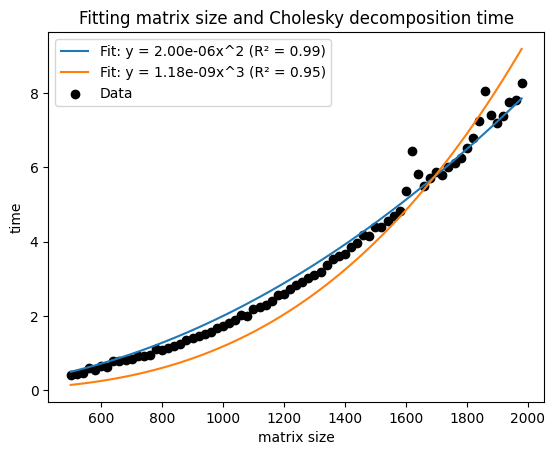

In [31]:
fit_to_models(
  'Fitting matrix size and Cholesky decomposition time',
  cholesky_Ns, times_for_cholesky_Ns,
  [model_x2, model_x3],
  ['x^2', 'x^3'],
  ['matrix size', 'time'])

Convergent if A is diagonally dominant: $\left| a_{ii} \right| > \sum_{\substack{j=1 \\ j \neq i}}^{n} \left| a_{ij} \right|$ \
$A$ is taken from Cholesky method above.\
Since a triangular matrix is symmetric and diagonally dominant, then Zeidel process applied on $A$ converges with error $\epsilon$.

In [76]:
# 11 Zeidel method
N = 3
A_start = tri_matrix(N, (-1,2,-1))
MIN_CONVERGENCE_ERROR = 1e-5
A = np.copy(A_start)
print(f'start A:\n{A}')
b_start = np.random.rand(N, 1)
b = np.copy(b_start)
d = np.diag(A)
# d is 1 / pivot of A row
d = np.apply_along_axis(lambda x: 1 / x, 0, d)
# precompute matrices used for reduction
A = np.transpose(np.transpose(A) * d) - I(N)
b = np.transpose(np.transpose(b) * d)
x = np.zeros((N, 1))
MAX_ITER_COUNT = 300
df = pd.DataFrame(columns=['iter.i', 'absolute error', 'max norm error', *(f'x_(i)_{k+1}' for k in range(N))])
for i in range(MAX_ITER_COUNT):
  x_prev = np.copy(x)
  for row in range(N):
    x[row] = b[row] - np.dot(A[row], x)
  max_norm_error = np.max(np.abs(x - x_prev))
  abs_error = magnitude(np.reshape(A_start @ x - b_start, (N, 1)))
  df.loc[len(df.index)] = [i+1, abs_error, max_norm_error, *(x_i[0] for x_i in x)]
  if max_norm_error < MIN_CONVERGENCE_ERROR:
    break
print(f'end error from 0:\n{A_start @ x - b_start}')  
print(f'solved x:\n{x}')  
print(f'real x:\n{np.linalg.solve(A_start, b_start)}')
df

start A:
[[ 2. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  2.]]
end error from 0:
[[-7.25896760e-06]
 [-3.62948380e-06]
 [-1.11022302e-16]]
solved x:
[[1.03307083]
 [1.45725788]
 [1.1742586 ]]
real x:
[[1.03307809]
 [1.45726514]
 [1.17426223]]


,iter.i,absolute error,max norm error,x_(i)_1,x_(i)_2,x_(i)_3
0,1.0,0.862443,0.698539,0.304446,0.505818,0.698539
1,2.0,0.531875,0.475724,0.557354,0.981541,0.936400
2,3.0,0.265938,0.237862,0.795216,1.219403,1.055331
3,4.0,0.132969,0.118931,0.914147,1.338334,1.114797
4,5.0,0.066484,0.059465,0.973613,1.397800,1.144529
5,6.0,0.033242,0.029733,1.003345,1.427532,1.159396
6,7.0,0.016621,0.014866,1.018212,1.442399,1.166829
7,8.0,0.008311,0.007433,1.025645,1.449832,1.170546
8,9.0,0.004155,0.003717,1.029361,1.453549,1.172404
9,10.0,0.002078,0.001858,1.031220,1.455407,1.173333


In [77]:
def iter_solve_zeidel(A_processed, b_processed, x, max_iter_count, MIN_CONVERGENCE_ERROR):
  for i in range(max_iter_count):
    x_prev = np.copy(x)
    for row in range(N):
      x[row] = b_processed[row] - np.dot(A_processed[row], x)
    max_norm_error = np.max(np.abs(x - x_prev))
    if max_norm_error < MIN_CONVERGENCE_ERROR:
      break
  return i

# change Ns to see iterations for them
Ns = range(10, 100, 10)
iters_for_N = []
MIN_CONVERGENCE_ERROR = 1e-4
MAX_ITER_COUNT = 10000

for N in Ns:
  A = tri_matrix(N, (-1,2,-1))
  b = np.random.rand(N, 1)
  d = np.diag(A)
  # d is 1 / pivot of A row
  d = np.apply_along_axis(lambda x: 1 / x, 0, d)
  # precompute matrices used for reduction
  A = np.transpose(np.transpose(A) * d) - I(N)
  b = np.transpose(np.transpose(b) * d)
  x = np.zeros((N, 1))
  iters_for_N.append(iter_solve_zeidel(A, b, x, MAX_ITER_COUNT, MIN_CONVERGENCE_ERROR))

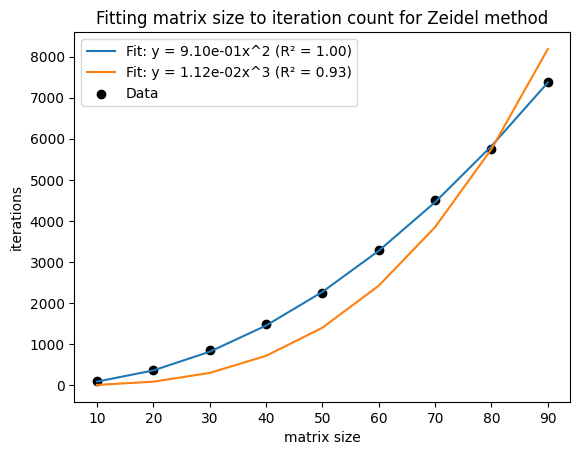

In [78]:
fit_to_models(
  'Fitting matrix size to iteration count for Zeidel method',
  Ns, iters_for_N,
  [model_x2, model_x3],
  ['x^2', 'x^3'],
  axis_labels=('matrix size', 'iterations'))

In [8]:
# 18 Joint gradients
N = 4
A = tri_matrix(N, (-1,2,-1))
x = np.zeros(N)
f = np.random.rand(N)
z = p = A @ np.transpose(x) - f
df = pd.DataFrame(columns=['iter.i', 'absolute error', 'sum norm error', *(f'x_(i)_{x_i}' for x_i in range(N))])
MIN_CONVERGENCE_ERROR = 1e-5
MCESQR = MIN_CONVERGENCE_ERROR * MIN_CONVERGENCE_ERROR
MAX_ITER_COUNT = 1e5
for i in range(int(MAX_ITER_COUNT)):
  z_prev = np.copy(z)
  x_prev = np.copy(x)
  r = A @ np.transpose(p)
  grad = np.dot(z, p) / np.dot(r, p)
  z = z - grad * r
  x = x - grad * p
  if (np.dot(z, z) < MCESQR):
    break
  p = z + np.dot(z, z) / np.dot(z_prev, z_prev) * p
  error = sum(abs(x - x_prev))
  absolute_error = magnitude(A @ np.transpose(x) - f)
  df.loc[len(df.index)] = [i+1, absolute_error, error, *(x_i for x_i in x)]

print(f'end error from 0:\n{A @ np.transpose(x) - f}')
print(f'real x:\n{np.linalg.solve(A, f)}')
df

end error from 0:
[ 1.11022302e-16 -2.22044605e-16  2.22044605e-16 -1.11022302e-16]
real x:
[1.05980173 1.34702138 1.43539426 1.20050351]


,iter.i,absolute error,sum norm error,x_(i)_0,x_(i)_1,x_(i)_2,x_(i)_3
0,1.0,1.042486,1.654120,0.565385,0.145519,0.236568,0.706648
1,2.0,0.195605,3.293320,0.953003,1.270310,1.459685,1.264442
2,3.0,0.016031,0.268587,1.061016,1.344087,1.438210,1.199120


In [36]:
# 18 Joint gradients
Ns = range(100, 2000, 20)
iters_for_N = []
MIN_CONVERGENCE_ERROR = 1e-1
MCESQR = MIN_CONVERGENCE_ERROR * MIN_CONVERGENCE_ERROR
MAX_ITER_COUNT = 1e5
for N in Ns:
  f = np.random.rand(N)
  A = tri_matrix(N, (-1,2,-1))
  x = np.zeros(N)
  z = p = A @ np.transpose(x) - f
  for i in range(int(MAX_ITER_COUNT)):
    z_prev = np.copy(z)
    x_prev = np.copy(x)
    r = A @ np.transpose(p)
    grad = np.dot(z, p) / np.dot(r, p)
    z = z - grad * r
    x = x - grad * p
    if (np.dot(z, z) < MCESQR):
      iters_for_N.append(i+1)
      break
    p = z + np.dot(z, z) / np.dot(z_prev, z_prev) * p
    error = sum(abs(x - x_prev))

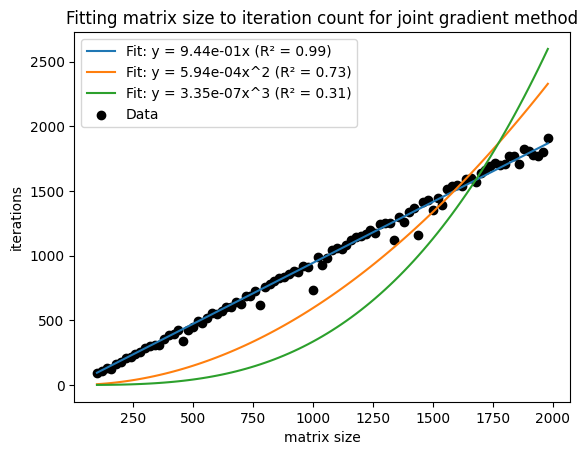

In [37]:
fit_to_models(
  'Fitting matrix size to iteration count for joint gradient method',
  Ns, iters_for_N,
  [model_x, model_x2, model_x3],
  ['x', 'x^2', 'x^3'],
  axis_labels=('matrix size', 'iterations'))